In [4]:
import matplotlib.pyplot as plt
from pathlib import Path
from typing import Tuple, Optional, Sequence, List
import json
import numpy as np
import pandas as pd
import nibabel as nib

from nibabel.affines import voxel_sizes
import SimpleITK as sitk

from nilearn.signal import clean
from nilearn.image import smooth_img

from scipy.interpolate import interp1d

import scipy.stats


def run_stem(run_id: str) -> str:
    return f"{SUBJECT}_{SESSION}_task-{TASK}_run-{run_id}"

def paths_for(run_id: str) -> Tuple[Path, Path]:
    stem = run_stem(run_id)
    nii = BASE_DIR / f"{stem}_pwd.nii.gz"
    jsn = BASE_DIR / f"{stem}_pwd.json"
    return nii, jsn

def load_nii(path: Path) -> Tuple[np.ndarray, nib.Nifti1Image, Tuple[float, float, float]]:
    nii = nib.load(str(path))
    data = nii.get_fdata(dtype=np.float32)  # (x, y, z, t)
    spacing = tuple(float(s) for s in voxel_sizes(nii.affine)[:3])
    return data, nii, spacing

def repetition_time(json_path: Path) -> float:
    with open(json_path, "r") as f:
        meta = json.load(f)
    vt = np.asarray(meta.get("VolumeTiming", []), dtype=np.float64)
    if vt.ndim != 1 or vt.size < 2 or not np.all(np.isfinite(vt)):
        raise ValueError(f"Invalid or missing VolumeTiming in {json_path}")
    return float(np.median(np.diff(vt)))


In [5]:
# ---------------------- CONFIG (revised) ----------------------
SUBJECT   = "sub-Forest001"
SESSION   = "ses-20260120"
TASK      = "audio"

# Single run with tasks one after another
RUN_IDS   = ["003"]                 # exactly one run
SINGLE_RUN_ID = RUN_IDS[0]

# I/O (unchanged)
BASE_DIR = Path(f"/Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003")
# BASE_DIR  = Path(f"/data/forest_la/{SUBJECT}/{SESSION}/fusi")
OUT_DIR = Path(f"/Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/analysis_output")
# OUT_BASE  = Path("/data/zach_processed_data/analysis_output") / f"{SUBJECT}_ses-{SESSION.split('-')[1]}"
# OUT_DIR   = OUT_BASE / f"{SUBJECT}_{SESSION}_task-{TASK}_EV"
TFM_DIR   = OUT_DIR / "transforms"
OUT_DIR.mkdir(parents=True, exist_ok=True)
TFM_DIR.mkdir(parents=True, exist_ok=True)


In [6]:
# -*- coding: utf-8 -*-
"""
Cell 1 (revised)
Single-run rigid realignment (no between-run step)

Outputs:
  - OUT_DIR/{stem}_realigned.nii.gz
  - TFM_DIR/{stem}_rigid6.tsv      (tx_mm .. rz_rad; one row per frame)
"""

MOTION_COLS = ["tx_mm","ty_mm","tz_mm","rx_rad","ry_rad","rz_rad"]


def realign_single_run(run_id: str):
    from fusiproc_utils3 import register_3d_image_stack, nan_mask  # same utility you used

    stem = run_stem(run_id)
    nii_path, _ = paths_for(run_id)
    print(f"\n=== Processing single run {stem} ===")

    data, nii, spacing = load_nii(nii_path)
    if data.ndim != 4:
        raise ValueError(f"{nii_path.name} is not 4D (shape={data.shape})")

    # Intra-run: realign to this run's temporal median (no censoring)
    mask = nan_mask(data)  # instead of finite_mask3d(data)
    reg_A, rigid_A, _, _, _ = register_3d_image_stack(
        np.where(np.isfinite(data), data, 0),
        reference='median',
        spacing=spacing,
        skip_indices=None,     # no frame censoring
        mask=mask,
        verbose=False,
    )

    # Save motion parameters (6 DOF)
    mot_df = pd.DataFrame(rigid_A.T, columns=MOTION_COLS)
    mot_path = TFM_DIR / f"{stem}_rigid6.tsv"
    mot_df.to_csv(mot_path, sep="\t", index=False)
    print(f"Saved motion TSV: {mot_path}")

    # Save the intra-run realigned stack in the ORIGINAL run grid
    out_path = OUT_DIR / f"{stem}_realigned.nii.gz"
    nib.save(nib.Nifti1Image(reg_A.astype(np.float32), nii.affine), str(out_path))
    print(f"Saved: {out_path}")

    return out_path, mot_path

if __name__ == "__main__":
    realign_single_run(SINGLE_RUN_ID)



=== Processing single run sub-Forest001_ses-20260120_task-audio_run-003 ===
Saved motion TSV: /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/analysis_output/transforms/sub-Forest001_ses-20260120_task-audio_run-003_rigid6.tsv
Saved: /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/analysis_output/sub-Forest001_ses-20260120_task-audio_run-003_realigned.nii.gz


In [7]:
"""
Cell 2 — Temporal processing with nilearn.signal.clean

For each run:
  • Regress Friston-24 motion terms (from Cell 1: *_rigid6.tsv)
  • Band-pass: high_pass=0.01 Hz, low_pass=0.30 Hz (clip low_pass to Nyquist)
  • Use TR from JSON VolumeTiming 
  • Detrend=True
  • Percent Signal Change
"""



# ---- Config ----
NOMINAL_HIGH_PASS = 0.01  # Hz
NOMINAL_LOW_PASS  = 0.30  # Hz

EXPECTED_MOTION_COLS = ["tx_mm","ty_mm","tz_mm","rx_rad","ry_rad","rz_rad"]

def make_friston24(motion_df: pd.DataFrame) -> np.ndarray:
    """
    Build Friston-24 regressors from 6 rigid-body columns.
    Returns array of shape (T, 24).
    """
    m = motion_df[EXPECTED_MOTION_COLS].to_numpy(dtype=np.float64)  # (T,6)
    # First differences, 0 for first frame (matches many pipelines)
    dm = np.vstack([np.zeros((1, m.shape[1]), dtype=np.float64), np.diff(m, axis=0)])
    return np.hstack([m, dm, m**2, dm**2])

for rid in RUN_IDS:
    stem     = run_stem(rid)
    in_path  = OUT_DIR / f"{stem}_realigned.nii.gz"
    mot_path = TFM_DIR / f"{stem}_rigid6.tsv"
    jsn_path = BASE_DIR / f"{stem}_pwd.json"

    if not in_path.exists():  raise FileNotFoundError(f"Missing aligned NIfTI: {in_path}")
    if not mot_path.exists(): raise FileNotFoundError(f"Missing motion TSV: {mot_path}")
    if not jsn_path.exists(): raise FileNotFoundError(f"Missing JSON sidecar: {jsn_path}")

    # --- Load data ---
    img  = nib.load(str(in_path))
    data = img.get_fdata(dtype=np.float32)  # (X,Y,Z,T)
    if data.ndim != 4:
        raise ValueError(f"{in_path.name} is not 4D (shape={data.shape})")
    X, Y, Z, T = data.shape

    # --- Timing & band limits ---
    tr  = repetition_time(jsn_path)
    nyq = 0.5 / tr
    low_pass  = min(NOMINAL_LOW_PASS, 0.99 * nyq)
    high_pass = NOMINAL_HIGH_PASS
    if not (high_pass < low_pass):
        raise ValueError(
            f"Invalid band: high_pass={high_pass} must be < low_pass={low_pass} "
            f"(Nyquist={nyq:.4f} Hz, TR={tr:.6f}s)."
        )

    # --- Motion regressors (Friston-24) ---
    mot_df = pd.read_csv(mot_path, sep=r"\s+", engine="python")
    mot_df = mot_df.rename(columns=lambda s: s.strip())

    confounds = make_friston24(mot_df)
    if confounds.shape[0] != T:
        raise ValueError(f"Confound rows ({confounds.shape[0]}) != time points ({T}) for run {rid}")

    # --- Clean with nilearn ---
    # nilearn.signal.clean expects shape (n_samples, n_features) => (T, V)
    Yt = data.reshape(-1, T).T
    cleaned = clean(
        Yt,
        confounds=confounds,
        detrend=True,
        standardize='psc',       
        low_pass=low_pass,
        high_pass=high_pass,
        t_r=tr,
        ensure_finite=True,      # avoids NaN propagation
    )

    cleaned_4d = cleaned.T.reshape(X, Y, Z, T).astype(np.float32)

    # --- Save NIfTI  ---
    hdr = img.header.copy()
    try:
        # Preserve spatial zooms, set temporal zoom to TR
        zxyz = hdr.get_zooms()[:3]
        hdr.set_zooms((zxyz[0], zxyz[1], zxyz[2], float(tr)))
    except Exception as e:
        print(f"Warning: could not set TR in header for {stem}: {e}")

    out_path = OUT_DIR / f"{stem}_realigned_clean.nii.gz"
    out_img  = nib.Nifti1Image(cleaned_4d, img.affine, hdr)
    nib.save(out_img, str(out_path))

    print(
        f"[{rid}] cleaned → {out_path.name} | TR={tr:.6f}s | "
        f"pass={high_pass:.4f}–{low_pass:.4f} Hz (Nyquist={nyq:.4f} Hz)"
    )


/var/folders/50/vlgy95sd2d1d6w1_l8pgqd1c0000gn/T/ipykernel_19769/2486030871.py:69: DeprecationWarning: The default strategy for standardize is currently 'zscore' which incorrectly uses population std to calculate sample zscores. The new strategy 'zscore_sample' corrects this behavior by using the sample std. In release 0.13, the default strategy will be replaced by the new strategy and the 'zscore' option will be removed. Please use 'zscore_sample' instead.
  cleaned = clean(
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/signal.py:122: RuntimeWarning: invalid value encountered in divide
  signals = (signals - mean_signals) / np.absolute(mean_signals)
/Users/clairenastaskin/Documents/Anise/.venv/lib/python3.9/site-packages/nilearn/signal.py:126: UserWarning: psc standardization strategy is meaningless for features that have a mean of 0. These time series are set to 0.
  warnings.warn(


[003] cleaned → sub-Forest001_ses-20260120_task-audio_run-003_realigned_clean.nii.gz | TR=1.804521s | pass=0.0100–0.2743 Hz (Nyquist=0.2771 Hz)


In [8]:
"""
Cell 3 — Spatial smoothing (Gaussian, 3 mm FWHM) with nilearn.image.smooth_img

Notes:
  • Uses Gaussian smoothing in millimeters
  • With 0.5 mm isotropic voxels, 3 mm FWHM ≈ 6 voxels FWHM 
  • Input:  *_realigned_clean.nii.gz  
  • Output: *_realigned_clean_smooth3mm.nii.gz
"""

FWHM_MM = 3.0

for rid in RUN_IDS:
    stem     = run_stem(rid)
    in_path  = OUT_DIR / f"{stem}_realigned_clean.nii.gz"
    jsn_path = BASE_DIR / f"{stem}_pwd.json"
    out_path = OUT_DIR / f"{stem}_realigned_clean_smooth3mm.nii.gz"

    if not in_path.exists():  raise FileNotFoundError(f"Missing cleaned NIfTI for run {rid}: {in_path}")
    if not jsn_path.exists(): raise FileNotFoundError(f"Missing JSON sidecar for run {rid}: {jsn_path}")

    img = nib.load(str(in_path))
    if len(img.shape) != 4:
        raise ValueError(f"{in_path.name} is not 4D (shape={img.shape})")
    X, Y, Z, T = img.shape

    zooms = voxel_sizes(img.affine)[:3]
    if not np.allclose(zooms, (0.5, 0.5, 0.5), atol=1e-3):
        print(f"  [warn] run {rid}: voxel sizes are {zooms} mm; proceeding with {FWHM_MM} mm FWHM.")

    # Smooth
    smoothed_img = smooth_img(img, fwhm=FWHM_MM)

    # Preserve TR in header
    tr = repetition_time(jsn_path)

    # Save like Cell 1/2, ensuring TR is stored (4th zoom)
    data = smoothed_img.get_fdata(dtype=np.float32)
    hdr  = img.header.copy()
    try:
        zxyz = hdr.get_zooms()[:3]
        hdr.set_zooms((zxyz[0], zxyz[1], zxyz[2], float(tr)))
    except Exception as e:
        print(f"Warning: could not set TR in header for {stem}: {e}")

    out_img = nib.Nifti1Image(data, img.affine, hdr)
    nib.save(out_img, str(out_path))

    fwhm_vox = tuple(FWHM_MM / z for z in zooms)
    sigma_mm = FWHM_MM / 2.354820045  # for reference
    print(
        f"[{rid}] smoothed → {out_path.name} | "
        f"FWHM={FWHM_MM:.1f} mm (~{fwhm_vox[0]:.1f}×{fwhm_vox[1]:.1f}×{fwhm_vox[2]:.1f} vox) | "
        f"σ≈{sigma_mm:.2f} mm | TR={tr:.6f}s"
    )


  [warn] run 003: voxel sizes are [0.51333332 0.51333332 0.51333332] mm; proceeding with 3.0 mm FWHM.
[003] smoothed → sub-Forest001_ses-20260120_task-audio_run-003_realigned_clean_smooth3mm.nii.gz | FWHM=3.0 mm (~5.8×5.8×5.8 vox) | σ≈1.27 mm | TR=1.804521s


In [9]:
"""
Cell 4 (revised) — Temporal alignment of within-run repetitions (linear interpolation)

Goal:
  • Use the single run's events table (multiple rows = repeated presentations)
  • Build one common grid [0, D] with step ~median(TR)
  • Interpolate each repetition onto that grid
  • Inputs:  *_realigned_clean_smooth3mm.nii.gz , JSON VolumeTiming, *_events.tsv
  • Outputs:
      - common_time_grid.tsv  (seconds relative to stimulus onset)
  • Interpolation is linear
"""

# ---------------------- OPTIONS ----------------------
# If your events.tsv contains multiple trial types, filter here (else None)
# Example: EVENT_FILTER = {"trial_type": ["testset"]}
EVENT_FILTER: Optional[dict] = None

# Make the grid duration conservative so every repetition fully covers it:
GRID_DURATION_STAT = "min"  # use "median" if you know durations are identical

def events_path(run_id: str) -> Path:
    return BASE_DIR / f"{run_stem(run_id)}_events.tsv"

def load_events_table(path: Path, event_filter: Optional[dict] = None) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing events TSV: {path}")
    df = pd.read_csv(path, sep="\t", comment="#")
    if "onset" not in df or "duration" not in df:
        raise ValueError(f"events.tsv must contain 'onset' and 'duration': {path}")

    if event_filter:
        for k, v in event_filter.items():
            if k in df.columns:
                if isinstance(v, (list, tuple, set)):
                    df = df[df[k].isin(v)]
                else:
                    df = df[df[k] == v]
    df = df.sort_values("onset").reset_index(drop=True)
    if df.empty:
        raise ValueError(f"No events left after filtering: {path}")
    return df[["onset", "duration"]]

def load_volume_timing(json_path: Path) -> np.ndarray:
    if not json_path.exists():
        raise FileNotFoundError(f"Missing JSON sidecar: {json_path}")
    with open(json_path, "r") as f:
        meta = json.load(f)
    vt = np.asarray(meta.get("VolumeTiming", []), dtype=np.float64)
    if vt.ndim != 1 or vt.size < 2 or not np.all(np.isfinite(vt)):
        raise ValueError(f"Invalid or missing VolumeTiming in {json_path}")
    return vt

def build_common_time_grid_single_run(run_id: str) -> np.ndarray:
    """
    Build a stimulus-relative grid [0, D] for one run.
    • D = min or median of durations across repetitions (use 'min' for safety)
    • Base step = median TR from JSON VolumeTiming
    """
    _, jsn = paths_for(run_id)
    vt = load_volume_timing(jsn)
    dt = float(np.median(np.diff(vt)))

    ev_df = load_events_table(events_path(run_id), EVENT_FILTER)
    durs = ev_df["duration"].to_numpy(dtype=np.float64)

    D = float(np.min(durs)) if GRID_DURATION_STAT == "min" else float(np.median(durs))
    if not (dt > 0 and D > 0 and np.isfinite(dt) and np.isfinite(D)):
        raise ValueError(f"Non-positive dt ({dt}) or duration ({D})")

    t = np.arange(0.0, D + 1e-12, dt, dtype=np.float64)
    if not np.isclose(t[-1], D, atol=1e-6):
        t = np.r_[t, D]

    grid_path = OUT_DIR / "common_time_grid.tsv"
    np.savetxt(
        grid_path, t, fmt="%.9f",
        header="t_sec  # seconds relative to stimulus onset", comments=""
    )
    print(f"Saved common grid → {grid_path} | N={t.size} | dt≈{dt:.6f}s | D≈{D:.6f}s")
    return t

def extract_repetitions_to_grid(run_id: str, t_common: np.ndarray, block_voxels: int = 131072):
    """
    Interpolate each event row onto the common grid.
    Returns:
      Y          : np.ndarray, shape (R, K, V)  with R=repetitions, K=len(t_common), V=X*Y*Z
      affine     : affine of the cleaned/smoothed 4D image
      spatial    : (X, Y, Z)
    """
    stem = run_stem(run_id)
    in_img_path = OUT_DIR / f"{stem}_realigned_clean_smooth3mm.nii.gz"
    if not in_img_path.exists():
        raise FileNotFoundError(f"Missing smoothed NIfTI: {in_img_path}")

    img = nib.load(str(in_img_path))
    data = img.get_fdata(dtype=np.float32)  # (X,Y,Z,T)
    if data.ndim != 4:
        raise ValueError(f"{in_img_path.name} is not 4D (shape={data.shape})")
    X, Y_, Z, T = data.shape
    V = X * Y_ * Z

    _, jsn_path = paths_for(run_id)
    vt_abs = load_volume_timing(jsn_path)    # absolute (run-relative) volume times
    if vt_abs.size != T:
        raise ValueError(f"VolumeTiming length ({vt_abs.size}) != time points ({T})")

    ev_df = load_events_table(events_path(run_id), EVENT_FILTER)
    reps = ev_df[["onset", "duration"]].to_numpy(dtype=np.float64)
    R = reps.shape[0]

    # Flatten time-last → time-first
    Yt = data.reshape(V, T).T  # (T, V)
    out = np.empty((R, t_common.size, V), dtype=np.float32)

    # Interpolate per repetition (block-wise over voxels for memory safety)
    for r, (onset, duration) in enumerate(reps):
        t_rel = vt_abs - onset  # seconds, 0 at repetition onset
        # We chose D = min/median(duration), so t_common should lie within each rep's domain.
        for b0 in range(0, V, block_voxels):
            b1 = min(V, b0 + block_voxels)
            f = interp1d(
                t_rel,
                Yt[:, b0:b1],
                kind="linear",
                axis=0,
                bounds_error=False,
                fill_value=np.nan,
                assume_sorted=True
            )
            out[r, :, b0:b1] = f(t_common).astype(np.float32, copy=False)

    # If your durations vary and some grid points fall outside a few reps,
    # using GRID_DURATION_STAT = "min" avoids NaNs.
    if not np.isfinite(out).all():
        # Drop any time indices that are NaN for any repetition (rare if D='min')
        keep_t = np.all(np.isfinite(out).all(axis=2), axis=0)
        if keep_t.sum() < 2:
            raise RuntimeError("Too many invalid time points after interpolation.")
        out = out[:, keep_t, :].copy()
        t_common = t_common[keep_t]
        print(f"[warn] Dropped {keep_t.size - keep_t.sum()} grid points with NaNs after interpolation.")

    return out, img.affine, (X, Y_, Z), t_common

# ---------------------- RUN ----------------------
# 1) Build common grid
t_common = build_common_time_grid_single_run(SINGLE_RUN_ID)

# 2) Interpolate repetitions to the grid
Y_rep, affine_ref, spatial_shape, t_common = extract_repetitions_to_grid(SINGLE_RUN_ID, t_common)

print(f"Within-run repetitions aligned: R={Y_rep.shape[0]}, T={Y_rep.shape[1]}, V={Y_rep.shape[2]}")


Saved common grid → /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/analysis_output/common_time_grid.tsv | N=8 | dt≈1.804521s | D≈12.000000s
Within-run repetitions aligned: R=96, T=8, V=294840


EV: using 96 repetitions, 8 time points, 294840 voxels.
Saved EV map → /Users/clairenastaskin/data/sub-Forest001/2026-01-20/ses-20260120/fusi/task-audio_run-003/analysis_output/sub-Forest001_ses-20260120_task-audio_EV_map.nii.gz


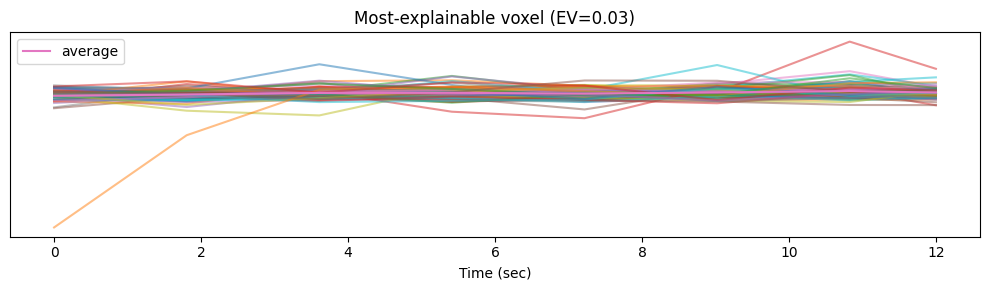

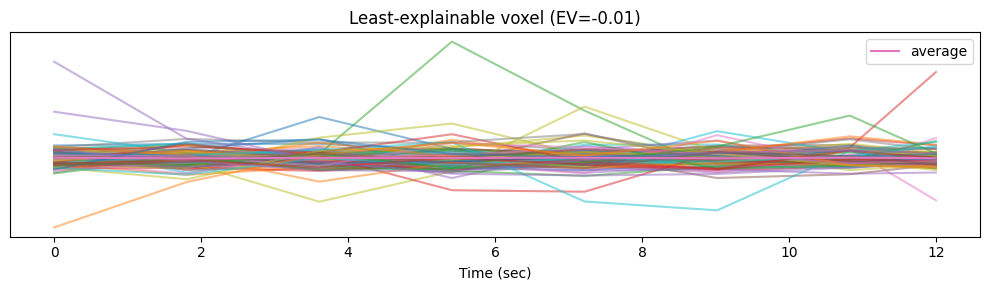

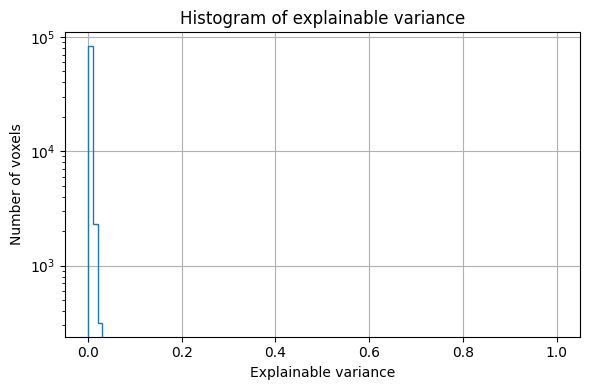

In [10]:
"""
Cell 5 (revised) — Compute and plot explainable variance (EV) from within-run repetitions
"""

GRID_TSV = OUT_DIR / "common_time_grid.tsv"

def explainable_variance(data, bias_correction=True, do_zscore=True):
    """
    data : array (n_repeats, n_times, n_voxels)
    """
    if do_zscore:
        data = scipy.stats.zscore(data, axis=1)  # z-score across time per repeat

    mean_var = data.var(axis=1, dtype=np.float64, ddof=1).mean(axis=0)
    var_mean = data.mean(axis=0).var(axis=0, dtype=np.float64, ddof=1)
    ev = var_mean / mean_var

    if bias_correction:
        n_repeats = data.shape[0]
        if n_repeats <= 1:
            # Can't bias-correct with a single repetition
            bias_correction = False
        else:
            ev = ev - (1 - ev) / (n_repeats - 1)
    return ev

# ---------- 1) Load common time grid (from revised Cell 4) ----------
if not GRID_TSV.exists():
    raise FileNotFoundError(f"Missing common grid: {GRID_TSV}")
t_grid = np.loadtxt(GRID_TSV, dtype=np.float64, ndmin=1, skiprows=1)
if t_grid.ndim != 1 or t_grid.size < 2:
    raise ValueError("Invalid stimulus grid (t_grid)")

# Use the repetition-aligned data produced by revised Cell 4:
R, K, V = Y_rep.shape
X, Y_, Z = spatial_shape
if V != X * Y_ * Z:
    raise RuntimeError("Shape mismatch between repetition data and spatial dims.")

print(f"EV: using {R} repetitions, {K} time points, {V} voxels.")
if R < 2:
    raise ValueError("Explainable variance requires at least 2 repetitions.")

# ---------- 2) Compute EV ----------
# Data are in percent-signal-change units after Cell 2; keep do_zscore=False (or True if preferred)
ev_vec = explainable_variance(Y_rep, bias_correction=True, do_zscore=False).astype(np.float32)

# ---------- 3) Save EV NIfTI (3D) ----------
ev_img = ev_vec.reshape(X, Y_, Z)
ev_path = OUT_DIR / f"{SUBJECT}_{SESSION}_task-{TASK}_EV_map.nii.gz"
nib.save(nib.Nifti1Image(ev_img, affine_ref), str(ev_path))
print(f"Saved EV map → {ev_path}")

# ---------- 4) Quick plots ----------
time_sec = t_common  # from revised Cell 4 (after any NaN trimming)
voxel_max = int(np.nanargmax(ev_vec))
voxel_min = int(np.nanargmin(ev_vec))

plt.figure(figsize=(10, 3))
plt.plot(time_sec, Y_rep[:, :, voxel_max].T, alpha=0.5)
plt.plot(time_sec, Y_rep[:, :, voxel_max].mean(0), label='average')
plt.xlabel("Time (sec)"); plt.title("Most-explainable voxel (EV=%.2f)" % float(ev_vec[voxel_max]))
plt.yticks([]); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 3))
plt.plot(time_sec, Y_rep[:, :, voxel_min].T, alpha=0.5)
plt.plot(time_sec, Y_rep[:, :, voxel_min].mean(0), label='average')
plt.xlabel("Time (sec)"); plt.title("Least-explainable voxel (EV=%.2f)" % float(ev_vec[voxel_min]))
plt.yticks([]); plt.legend(); plt.tight_layout(); plt.show()

plt.figure(figsize=(6,4))
plt.hist(ev_vec[np.isfinite(ev_vec)], bins=np.linspace(0, 1, 100), log=True, histtype='step')
plt.xlabel("Explainable variance"); plt.ylabel("Number of voxels")
plt.title("Histogram of explainable variance"); plt.grid(True); plt.tight_layout(); plt.show()
